In [6]:
# ==============================================================================
# 1. Game Environment Implementation (Blackjack)
# ==============================================================================
# 定义游戏环境。
# 定义状态空间、动作空间和奖励函数。
# ==============================================================================

import numpy as np
import random
from collections import defaultdict

class BlackjackEnvironment:
    def __init__(self):
        """
        初始化游戏环境。
        定义动作空间：0 = Stand (停牌), 1 = Hit (要牌)
        """
        self.action_space = [0, 1]
        self.reset()

    def reset(self):
        """
        重置游戏状态，开始新的一局。
        返回：初始状态 (player_sum, dealer_card, usable_ace)
        """
        # 生成牌堆：无限副牌模式简化实现，每次抽牌独立随机
        # 牌面值：2-9 对应数值，10/J/Q/K 对应 10，A 对应 11
        self.deck = [2, 3, 4, 5, 6, 7, 8, 9, 10, 10, 10, 10, 11] * 4

        # 初始化玩家和庄家的手牌
        self.player_hand = [self.draw_card(), self.draw_card()]
        self.dealer_hand = [self.draw_card(), self.draw_card()]

        # 检查是否有可用的 Ace (Usable Ace)
        # 如果手中有 Ace 且总和不超过 21，则 Ace 算作 11，否则算作 1
        self.usable_ace = self.has_usable_ace(self.player_hand)

        # 计算当前点数
        self.player_sum = self.calculate_sum(self.player_hand)
        self.dealer_sum = self.calculate_sum(self.dealer_hand)

        # 返回初始状态：(玩家点数，庄家明牌，是否有可用 Ace)
        # 庄家明牌取 dealer_hand[0]
        return self.get_state()

    def draw_card(self):
        """随机抽一张牌"""
        return random.choice(self.deck)

    def calculate_sum(self, hand):
        """计算手牌点数，处理 Ace 的逻辑"""
        total = sum(hand)
        # 如果总和超过 21 且有 Ace (值为 11)，将一个 Ace 变为 1 (减去 10)
        while total > 21 and 11 in hand:
            total -= 10
            hand[hand.index(11)] = 1 # 修改手牌中的 Ace 为 1
        return total

    def has_usable_ace(self, hand):
        """判断是否有可用 Ace (即算作 11 也不会爆牌)"""
        return 11 in hand and sum(hand) <= 21

    def get_state(self):
        """
        获取当前状态。
        为了 Q-Learning 方便，将状态简化为离散元组：
        (player_sum, dealer_card, usable_ace)
        usable_ace: True (1) or False (0)
        """
        return (self.player_sum, self.dealer_hand[0], int(self.usable_ace))

    def step(self, action):
        """
        执行动作并返回结果。
        参数：action (0=Stand, 1=Hit)
        返回：next_state, reward, done
        """
        done = False
        reward = 0

        if action == 1:  # Hit (要牌)
            self.player_hand.append(self.draw_card())
            self.usable_ace = self.has_usable_ace(self.player_hand)
            self.player_sum = self.calculate_sum(self.player_hand)

            # 检查玩家是否爆牌 (Bust)
            if self.player_sum > 21:
                done = True
                reward = -1  # 玩家爆牌，输
            # 如果没爆牌，游戏继续，奖励为 0
            else:
                done = False
                reward = 0

        elif action == 0:  # Stand (停牌)
            # 玩家停牌，庄家开始玩
            # 庄家规则：通常庄家点数小于 17 必须要牌
            while self.calculate_sum(self.dealer_hand) < 17:
                self.dealer_hand.append(self.draw_card())

            self.dealer_sum = self.calculate_sum(self.dealer_hand)
            done = True

            # 判断胜负
            if self.dealer_sum > 21 or self.player_sum > self.dealer_sum:
                reward = 1   # 赢
            elif self.player_sum == self.dealer_sum:
                reward = 0   # 平局
            else:
                reward = -1  # 输

        next_state = self.get_state()
        return next_state, reward, done

# ==============================================================================
# 2.Test Game Environment
# ==============================================================================
# 在开始训练 Agent 之前，确保游戏逻辑正确。
# 以下代码模拟随机操作来测试环境。

def test_environment():
    env = BlackjackEnvironment()
    state = env.reset()
    print(f"Initial state: {state}")
    print(f"Player hand: {env.player_hand}, sum: {env.player_sum}")
    print(f"Dealer hand: {env.dealer_hand}, showing: {env.dealer_hand[0]}")

    # Simulate random actions
    for _ in range(5):
        action = random.choice([0, 1])
        action_name = "Stand" if action == 0 else "Hit"
        next_state, reward, done = env.step(action)
        print(f"Action: {action_name} -> New state: {next_state}, Reward: {reward}, Done: {done}")
        if done:
            break

# 运行测试
test_environment()

Initial state: (11, 8, 0)
Player hand: [7, 4], sum: 11
Dealer hand: [8, 11], showing: 8
Action: Hit -> New state: (21, 8, 0), Reward: 0, Done: False
Action: Stand -> New state: (21, 8, 0), Reward: 1, Done: True


Starting optimized training for 50000 episodes...
------------------------------------------------------------
Episode 1000/50000 | Avg Reward: -0.319 | Win Rate: 31.0% | States: 232
Episode 2000/50000 | Avg Reward: -0.264 | Win Rate: 34.2% | States: 259
Episode 3000/50000 | Avg Reward: -0.227 | Win Rate: 35.3% | States: 271
Episode 4000/50000 | Avg Reward: -0.168 | Win Rate: 38.4% | States: 281
Episode 5000/50000 | Avg Reward: -0.082 | Win Rate: 42.3% | States: 287
Episode 6000/50000 | Avg Reward: -0.062 | Win Rate: 42.8% | States: 288
Episode 7000/50000 | Avg Reward: -0.073 | Win Rate: 42.1% | States: 289
Episode 8000/50000 | Avg Reward: -0.002 | Win Rate: 46.0% | States: 291
Episode 9000/50000 | Avg Reward: -0.103 | Win Rate: 41.0% | States: 291
Episode 10000/50000 | Avg Reward: -0.099 | Win Rate: 40.3% | States: 292
Episode 11000/50000 | Avg Reward: -0.049 | Win Rate: 43.4% | States: 292
Episode 12000/50000 | Avg Reward: -0.072 | Win Rate: 42.1% | States: 292
Episode 13000/50000 | 

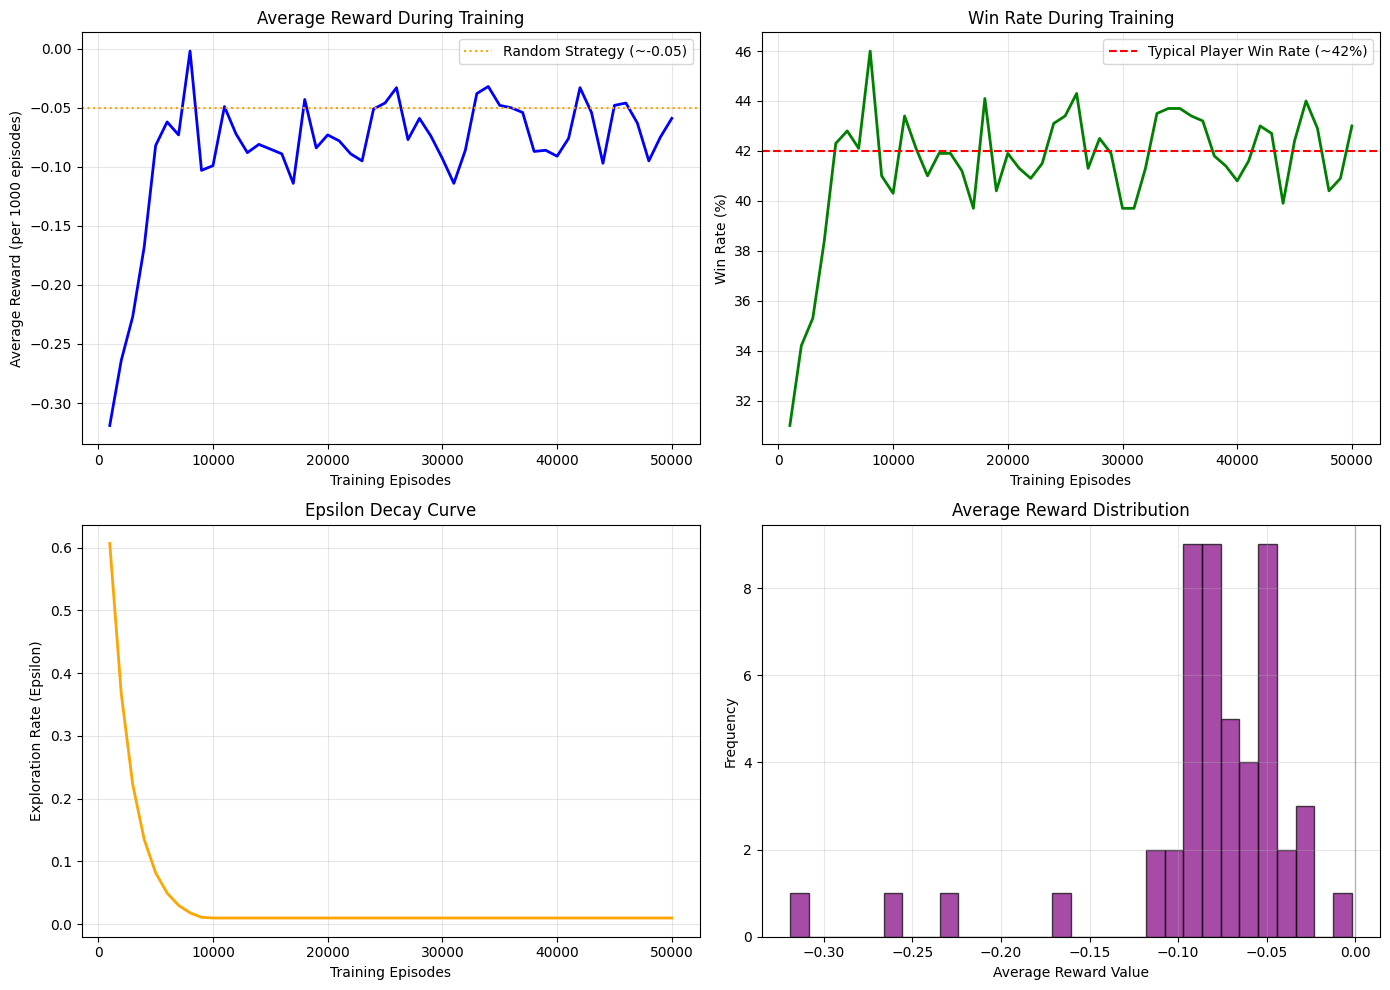

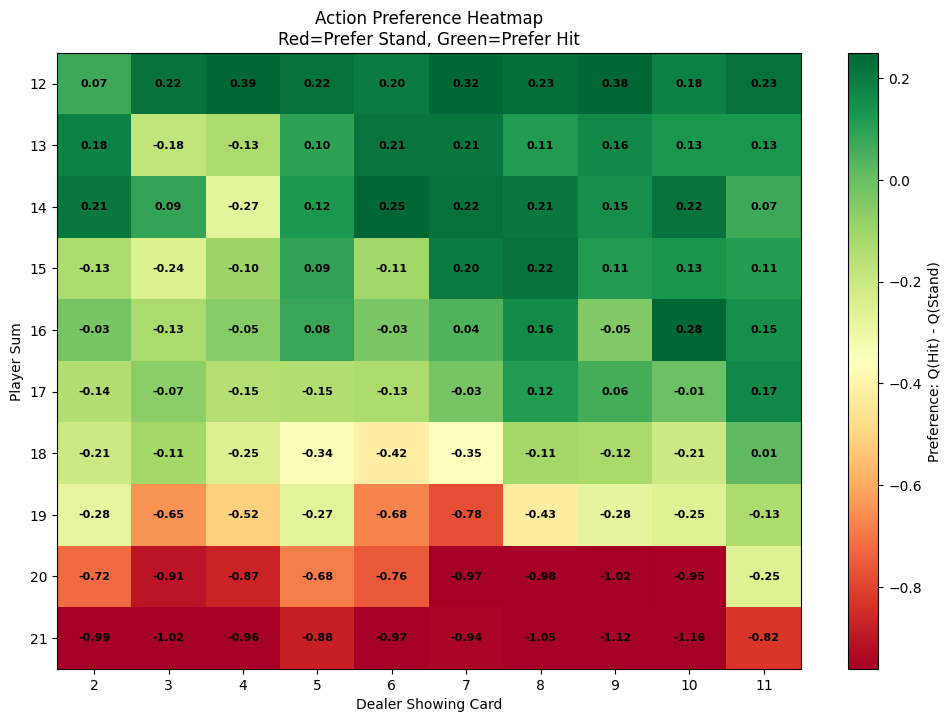

In [ ]:
# ==============================================================================
# 3. Q-Learning Agent Implementation
# ==============================================================================
# 实现 Q-Learning 算法的核心逻辑
# 包括 Q-Table 管理、动作选择策略、Q 值更新
# ==============================================================================

import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
import random

class QLearningAgent:
    def __init__(self, alpha=0.1, gamma=0.95, epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.01):
        """
        初始化 Q-Learning 代理

        参数:
        - alpha: 学习率，控制更新幅度
        - gamma: 折扣因子，未来奖励的权重
        - epsilon: 初始探索率
        - epsilon_decay: 探索率衰减系数
        - epsilon_min: 最小探索率
        """
        self.alpha = alpha          # 学习率
        self.gamma = gamma          # 折扣因子
        self.epsilon = epsilon      # 探索率
        self.epsilon_decay = epsilon_decay  # 探索率衰减
        self.epsilon_min = epsilon_min      # 最小探索率

        # Q-Table: 使用 defaultdict 自动处理未见过的状态
        # 结构：Q[state][action] = value
        self.q_table = defaultdict(lambda: np.zeros(2))  # 2 个动作：Stand(0), Hit(1)

        # 记录训练历史
        self.training_history = []

    def get_action(self, state, training=True):
        """
        根据 ε-greedy 策略选择动作

        参数:
        - state: 当前状态
        - training: 是否在训练中 (训练时使用ε-greedy，测试时纯贪婪)

        返回:
        - action: 选择的动作 (0 或 1)
        """
        # 测试阶段不使用探索，直接选最优
        if not training:
            return np.argmax(self.q_table[state])

        # 训练阶段：ε-greedy 策略
        if random.random() < self.epsilon:
            # 探索：随机选择动作
            return random.choice([0, 1])
        else:
            # 利用：选择 Q 值最大的动作
            return np.argmax(self.q_table[state])

    def update(self, state, action, reward, next_state, done):
        """
        更新 Q-Table

        使用 Q-Learning 更新公式：
        Q(s,a) = Q(s,a) + α * [r + γ * max(Q(s',a')) - Q(s,a)]
        """
        # 当前 Q 值
        current_q = self.q_table[state][action]

        # 如果游戏结束，下一状态的最大 Q 值为 0
        if done:
            max_next_q = 0
        else:
            max_next_q = np.max(self.q_table[next_state])

        # Q-Learning 更新公式
        new_q = current_q + self.alpha * (reward + self.gamma * max_next_q - current_q)
        self.q_table[state][action] = new_q

    def decay_epsilon(self):
        """
        衰减探索率 ε
        随着训练进行，逐渐减少随机探索，增加利用已知策略
        """
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

    def get_q_table_stats(self):
        """
        获取 Q-Table 的统计信息，用于分析和报告
        """
        if len(self.q_table) == 0:
            return {"states": 0, "avg_q": 0}

        all_values = []
        for state in self.q_table:
            all_values.extend(self.q_table[state])

        return {
            "states": len(self.q_table),
            "avg_q": np.mean(all_values),
            "max_q": np.max(all_values),
            "min_q": np.min(all_values)
        }

# ==============================================================================
# 4. Training Function (MODIFIED for 50,000 episodes)
# ==============================================================================

def train_agent_optimized(episodes=50000, verbose=True):
    """
    Optimized training: slower epsilon decay + lower learning rate
    """
    env = BlackjackEnvironment()
    agent = QLearningAgent(
        alpha=0.05,
        gamma=0.95,
        epsilon=1.0,
        epsilon_decay=0.9995,
        epsilon_min=0.01
    )

    rewards_window = []
    history = {"episodes": [], "avg_rewards": [], "win_rates": [], "epsilon_values": []}

    print(f"Starting optimized training for {episodes} episodes...")
    print("-" * 60)

    for episode in range(episodes):
        state = env.reset()
        total_reward = 0
        done = False

        while not done:
            action = agent.get_action(state, training=True)
            next_state, reward, done = env.step(action)
            agent.update(state, action, reward, next_state, done)
            state = next_state
            total_reward += reward

        agent.decay_epsilon()
        rewards_window.append(total_reward)

        if (episode + 1) % 1000 == 0:
            avg_reward = np.mean(rewards_window[-1000:])
            win_rate = (rewards_window[-1000:].count(1) / 1000) * 100

            history["episodes"].append(episode + 1)
            history["avg_rewards"].append(avg_reward)
            history["win_rates"].append(win_rate)
            history["epsilon_values"].append(agent.epsilon)

            if verbose:
                print(f"Episode {episode+1}/{episodes} | "
                      f"Avg Reward: {avg_reward:.3f} | "
                      f"Win Rate: {win_rate:.1f}% | "
                      f"States: {len(agent.q_table)}")

    print("-" * 60)
    print(f"Training completed! Final win rate: {history['win_rates'][-1]:.1f}%")
    print(f"Number of states explored: {len(agent.q_table)}")

    return agent, history

# ==============================================================================
# 5. Evaluation Function
# ==============================================================================

def evaluate_agent(agent, episodes=1000):
    """
    Evaluate the trained agent's performance (greedy policy, no exploration)
    """
    env = BlackjackEnvironment()
    wins = 0
    losses = 0
    draws = 0

    for _ in range(episodes):
        state = env.reset()
        done = False

        while not done:
            action = agent.get_action(state, training=False)  # test mode
            state, reward, done = env.step(action)

        if reward == 1:
            wins += 1
        elif reward == -1:
            losses += 1
        else:
            draws += 1

    win_rate = (wins / episodes) * 100
    print(f"\n=== Evaluation Results ({episodes} episodes) ===")
    print(f"Win rate: {win_rate:.2f}%")
    print(f"Wins: {wins} | Losses: {losses} | Draws: {draws}")

    return {"win_rate": win_rate, "wins": wins, "losses": losses, "draws": draws}

# ==============================================================================
# 6. Visualization Functions
# ==============================================================================


def plot_training_history(history):
    """
    Plot training history curves (Fixed labels)
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Average Reward Curve
    axes[0, 0].plot(history["episodes"], history["avg_rewards"], 'b-', linewidth=2)
    axes[0, 0].axhline(y=-0.05, color='orange', linestyle=':', label='Random Strategy (~-0.05)')
    axes[0, 0].set_xlabel('Training Episodes')
    axes[0, 0].set_ylabel('Average Reward (per 1000 episodes)')
    axes[0, 0].set_title('Average Reward During Training')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # 2. Win Rate Curve
    axes[0, 1].plot(history["episodes"], history["win_rates"], 'g-', linewidth=2)
    axes[0, 1].axhline(y=42, color='r', linestyle='--', label='Typical Player Win Rate (~42%)')
    axes[0, 1].set_xlabel('Training Episodes')
    axes[0, 1].set_ylabel('Win Rate (%)')
    axes[0, 1].set_title('Win Rate During Training')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # 3. Epsilon Decay Curve
    axes[1, 0].plot(history["episodes"], history["epsilon_values"], 'orange', linewidth=2)
    axes[1, 0].set_xlabel('Training Episodes')
    axes[1, 0].set_ylabel('Exploration Rate (Epsilon)')
    axes[1, 0].set_title('Epsilon Decay Curve')
    axes[1, 0].grid(True, alpha=0.3)

    # 4. Reward Distribution Histogram
    axes[1, 1].hist(history["avg_rewards"], bins=30, color='purple', alpha=0.7, edgecolor='black')


    axes[1, 1].axvline(x=0, color='gray', linestyle='-', linewidth=1, alpha=0.5)

    axes[1, 1].set_xlabel('Average Reward Value')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title('Average Reward Distribution')
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()



def plot_q_table_final(agent):
    """
    Final Heatmap: Display Q(Hit) - Q(Stand) preference difference
    Red = Prefer Stand, Green = Prefer Hit
    """
    player_sums = list(range(12, 22))
    dealer_cards = list(range(2, 12))

    # Store preference values: Q(Hit) - Q(Stand)
    preference_values = []

    for i, p_sum in enumerate(player_sums):
        row_pref = []
        for j, d_card in enumerate(dealer_cards):
            state_with_ace = (p_sum, d_card, 1)
            state_without_ace = (p_sum, d_card, 0)

            prefs = []
            for state in [state_with_ace, state_without_ace]:
                if state in agent.q_table:
                    q_hit = agent.q_table[state][1]
                    q_stand = agent.q_table[state][0]
                    prefs.append(q_hit - q_stand)

            if len(prefs) > 0:
                row_pref.append(np.mean(prefs))
            else:
                row_pref.append(np.nan)

        preference_values.append(row_pref)

    preference_values = np.array(preference_values)

    # Calculate color range
    valid_values = preference_values[~np.isnan(preference_values)]
    if len(valid_values) > 0:
        # 使用百分位数，避免极端值影响颜色
        vmin = np.percentile(valid_values[valid_values < 0], 15) if len(valid_values[valid_values < 0]) > 0 else -0.8
        vmax = np.percentile(valid_values[valid_values > 0], 85) if len(valid_values[valid_values > 0]) > 0 else 0.3

        # 缩小颜色范围，让颜色更浅
        vmin = min(vmin, -0.6)
        vmax = max(vmax, 0.25)
    else:
        vmin, vmax = -0.6, 0.25

    # Create heatmap
    plt.figure(figsize=(12, 8))
    masked_values = np.ma.masked_invalid(preference_values)
    im = plt.imshow(masked_values, cmap='RdYlGn', aspect='auto',
                    vmin=vmin, vmax=vmax, interpolation='nearest')
    plt.colorbar(im, label='Preference: Q(Hit) - Q(Stand)')
    plt.xticks(range(len(dealer_cards)), dealer_cards)
    plt.yticks(range(len(player_sums)), player_sums)
    plt.xlabel('Dealer Showing Card')
    plt.ylabel('Player Sum')
    plt.title('Action Preference Heatmap\nRed=Prefer Stand, Green=Prefer Hit')

    # Add value annotations
    for i in range(len(player_sums)):
        for j in range(len(dealer_cards)):
            val = preference_values[i, j]
            if not np.isnan(val):
                # all black text
                plt.text(j, i, f'{val:.2f}', ha='center', va='center',
                        color='black', fontsize=8, fontweight='bold')
            else:
                plt.text(j, i, 'N/A', ha='center', va='center',
                        color='gray', fontsize=6, fontweight='bold')





# ==============================================================================
# 7.Train and Plot (50,000 episodes)
# ==============================================================================

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)

# Train agent
optimized_agent, optimized_history = train_agent_optimized(episodes=50000, verbose=True)

# Evaluate trained agent
evaluate_agent(optimized_agent, episodes=1000)

# Plot training curves
plot_training_history(optimized_history)

# Plot Q-Table heatmap
plot_q_table_final(optimized_agent)

In [ ]:
# ==============================================================================
# 8. Interactive User Interface (UI)
# ==============================================================================

import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import time

class BlackjackUI:
    def __init__(self, agent=None):
        self.env = BlackjackEnvironment()
        self.agent = agent
        self.game_over = False
        self.total_reward = 0
        self.games_played = 0
        self.games_won = 0
        self.ai_playing = False  # 防止 AI 播放期间重复点击
        self.create_widgets()

    def create_widgets(self):
        # 标题
        self.title = widgets.HTML(value="""
            <h2 style='color: #2E86C1; text-align: center; margin: 10px 0;'>🎰 Blackjack - Q-Learning Demo</h2>
        """)

        # 输出区域
        self.cards_box = widgets.Output()
        self.status_box = widgets.Output()
        self.reward_box = widgets.Output()
        self.stats_box = widgets.Output()

        # 速度滑块
        self.speed_slider = widgets.FloatSlider(
            value=1.5,
            min=0.5,
            max=3.0,
            step=0.1,
            description='⏱️ AI Speed:',
            style={'description_width': 'initial'},
            layout=widgets.Layout(width='300px', margin='10px auto')
        )

        # 按钮
        button_layout = widgets.Layout(width='120px', height='50px', font_size='16px', margin='0 5px')
        self.hit_button = widgets.Button(description='🃏 Hit', button_style='success', layout=button_layout)
        self.stand_button = widgets.Button(description='🛑 Stand', button_style='danger', layout=button_layout)
        self.new_game_button = widgets.Button(description='🔄 New Game', button_style='info', layout=button_layout)
        self.ai_play_button = widgets.Button(description='🤖 AI Play', button_style='warning', layout=button_layout)
        self.reset_stats_button = widgets.Button(description='📊 Reset Stats', button_style='primary', layout=button_layout)

        # 绑定事件
        self.hit_button.on_click(self.on_hit)
        self.stand_button.on_click(self.on_stand)
        self.new_game_button.on_click(self.on_new_game)
        self.ai_play_button.on_click(self.on_ai_play)
        self.reset_stats_button.on_click(self.on_reset_stats)

        # 按钮布局
        self.button_box = widgets.HBox([
            self.hit_button,
            self.stand_button,
            self.new_game_button,
            self.ai_play_button,
            self.reset_stats_button
        ], layout=widgets.Layout(justify_content='center', margin='10px 0'))

        # 整体布局
        self.ui = widgets.VBox([
            self.title,
            self.stats_box,
            self.cards_box,
            self.status_box,
            self.reward_box,
            self.speed_slider,
            self.button_box
        ], layout=widgets.Layout(align_items='center'))

        self.start_new_game()

    def get_card_display(self, hand, hide_second=False, is_dealer=False):
        """
        生成扑克牌 HTML 显示
        """
        cards_html = ""
        for i, card in enumerate(hand):
            if card == 11:
                rank = 'A'
            elif card == 10:
                rank = '10'
            else:
                rank = str(card)

            suits = ['♠', '♥', '♦', '♣']
            suit = suits[i % 4]

            if is_dealer and hide_second and i == 1:
                cards_html += '''
                <div style="width:50px; height:75px; background:#2E86C1; border:2px solid white;
                            border-radius:5px; color:white; display:inline-block; margin:3px;
                            text-align:center; line-height:75px; font-size:24px; font-weight:bold;">?</div>
                '''
            else:
                color = 'red' if suit in ['♥', '♦'] else 'black'
                cards_html += f'''
                <div style="width:50px; height:75px; background:white; border:2px solid black;
                            border-radius:5px; color:{color}; display:inline-block; margin:3px;
                            text-align:center; font-size:16px; font-weight:bold; box-shadow:2px 2px 5px rgba(0,0,0,0.3);">
                    <div style="padding:3px;">{rank}</div>
                    <div style="font-size:20px;">{suit}</div>
                    <div style="padding:3px;">{rank}</div>
                </div>
                '''
        return cards_html

    def start_new_game(self):
        self.state = self.env.reset()
        self.game_over = False
        self.current_reward = 0
        self.games_played += 1
        self.update_display()

    def update_display(self):
        player_sum, dealer_card, usable_ace = self.state

        with self.cards_box:
            clear_output()

            # 玩家手牌 Usable Ace 显示在 Total 后面，如果爆牌则显示 BUST!
            player_cards_html = self.get_card_display(self.env.player_hand)
            ace_text = ' <span style="color:yellow;">(Usable Ace)</span>' if usable_ace else ''
            player_bust_text = ' <span style="color:yellow; font-weight:bold;">(BUST!)</span>' if self.game_over and self.env.player_sum > 21 else ''
            display(HTML(f"""
                <div style='background:#27ae60; padding:15px; border-radius:10px; margin:10px; width:600px;'>
                    <h3 style='color:white; margin:0 0 10px 0;'>🎴 Player (You)</h3>
                    <div>{player_cards_html}</div>
                    <h4 style='color:white; margin:10px 0 0 0;'>Total: {player_sum} points{ace_text}{player_bust_text}</h4>
                </div>
            """))

            # 庄家手牌 如果爆牌则显示 BUST!
            dealer_cards_html = self.get_card_display(
                self.env.dealer_hand,
                hide_second=not self.game_over,
                is_dealer=True
            )
            if self.game_over:
                dealer_score_text = f"Total: {self.env.dealer_sum} points"
                dealer_bust_text = ' <span style="color:yellow; font-weight:bold;">(BUST!)</span>' if self.env.dealer_sum > 21 else ''
            else:
                dealer_score_text = f"Showing: {self.env.dealer_hand[0]} points"
                dealer_bust_text = ''  # 游戏未结束不可能爆牌
            display(HTML(f"""
                <div style='background:#c0392b; padding:15px; border-radius:10px; margin:10px; width:600px;'>
                    <h3 style='color:white; margin:0 0 10px 0;'>🎴 Dealer</h3>
                    <div>{dealer_cards_html}</div>
                    <h4 style='color:white; margin:10px 0 0 0;'>{dealer_score_text}{dealer_bust_text}</h4>
                </div>
            """))

        # 游戏状态（包含比分对比）
        with self.status_box:
            clear_output()
            if self.game_over:
                # 显示玩家 vs 庄家点数
                score_text = f"{self.env.player_sum} vs {self.env.dealer_sum}"

                if self.current_reward > 0:
                    status = "✅ YOU WIN!"
                    color = "#2ecc71"
                    self.games_won += 1
                elif self.current_reward < 0:
                    status = "❌ YOU LOSE!"
                    color = "#e74c3c"
                else:
                    status = "🤝 DRAW!"
                    color = "#f39c12"

                display(HTML(f"""
                    <div style='background:{color}; padding:15px; border-radius:10px; margin:10px; text-align:center; width:600px;'>
                        <h2 style='color:white; margin:0;'>{status}</h2>
                        <p style='color:white; margin:5px 0 0 0; font-size:18px;'>{score_text}</p>
                    </div>
                """))

                self.hit_button.disabled = True
                self.stand_button.disabled = True
            else:
                display(HTML("""
                    <div style='background:#3498db; padding:15px; border-radius:10px; margin:10px; text-align:center; width:600px;'>
                        <h3 style='color:white; margin:0;'>🎮 Your Turn - Choose Action</h3>
                    </div>
                """))
                self.hit_button.disabled = False
                self.stand_button.disabled = False

        # 累计 Reward
        with self.reward_box:
            clear_output()
            if self.game_over:
                display(HTML(f"""
                    <div style='text-align:center; font-size:18px; margin:10px;'>
                        💰 This Round: <strong style='color:{"green" if self.current_reward > 0 else "red"};'>
                        {self.current_reward:+d}</strong> &nbsp;|&nbsp;
                        🏆 Total Reward: <strong style='color:#f39c12;'>{self.total_reward + self.current_reward:+d}</strong>
                    </div>
                """))
                self.total_reward += self.current_reward
            else:
                display(HTML(f"""
                    <div style='text-align:center; margin:10px; font-size:16px;'>
                        💰 This Round: 0 (game continues) &nbsp;|&nbsp;
                        🏆 Total Reward: <strong style='color:#f39c12;'>{self.total_reward:+d}</strong>
                    </div>
                """))

        # 统计信息
        with self.stats_box:
            clear_output()
            win_rate = (self.games_won / self.games_played * 100) if self.games_played > 0 else 0
            display(HTML(f"""
                <div style='background:#34495e; padding:10px; border-radius:5px; margin:10px; text-align:center; width:600px;'>
                    <span style='color:white; font-size:16px;'>📈 Games: {self.games_played} |
                    Wins: {self.games_won} |
                    Win Rate: <strong style='color:#f1c40f;'>{win_rate:.1f}%</strong></span>
                </div>
            """))

    def state_description(self, state):
        player_sum, dealer_card, usable_ace = state
        ace_str = "Yes" if usable_ace else "No"
        return f"Player sum: {player_sum}, Dealer card: {dealer_card}, Usable ace: {ace_str}"

    def on_hit(self, b):
        if not self.game_over and not self.ai_playing:
            self.state, self.current_reward, self.game_over = self.env.step(1)
            self.update_display()

    def on_stand(self, b):
        if not self.game_over and not self.ai_playing:
            self.state, self.current_reward, self.game_over = self.env.step(0)
            self.update_display()

    def on_new_game(self, b):
        if not self.ai_playing:
            self.start_new_game()

    def on_reset_stats(self, b):
        """重置统计数据（总局数、胜场、累计奖励）"""
        self.total_reward = 0
        self.games_played = 0
        self.games_won = 0
        self.start_new_game()  # 重新开始一局
        # 更新统计显示
        with self.stats_box:
            clear_output()
            display(HTML("""
                <div style='background:#34495e; padding:15px; border-radius:10px; margin:10px; text-align:center; width:600px;'>
                    <span style='color:white; font-size:16px;'>📈 Games: 0 | Wins: 0 | Win Rate: 0.0%</span>
                </div>
            """))
        with self.reward_box:
            clear_output()
            display(HTML("""
                <div style='text-align:center; margin:10px; font-size:16px;'>
                    💰 This Round: 0 (game continues) &nbsp;|&nbsp; 🏆 Total Reward: <strong style='color:#f39c12;'>+0</strong>
                </div>
            """))

    def on_ai_play(self, b):
        if self.agent is None:
            with self.status_box:
                print("⚠️ Please train the agent first!")
            return

        if self.ai_playing:
            return  # 防止重复点击

        self.ai_playing = True
        self.ai_play_button.disabled = True
        self.hit_button.disabled = True
        self.stand_button.disabled = True
        self.reset_stats_button.disabled = True

        self.start_new_game()

        with self.status_box:
            clear_output()
            display(HTML("""
                <div style='background:#9b59b6; padding:15px; border-radius:10px; margin:10px; text-align:center; width:600px;'>
                    <h3 style='color:white; margin:0;'>🤖 AI is playing...</h3>
                </div>
            """))

        # 从滑块获取延迟时间
        delay = self.speed_slider.value

        step_count = 0
        while not self.game_over:
            action = self.agent.get_action(self.state, training=False)
            action_name = "HIT 🃏" if action == 1 else "STAND 🛑"
            step_count += 1

            # 描述当前状态
            state_desc = self.state_description(self.state)

            with self.status_box:
                clear_output()
                display(HTML(f"""
                    <div style='background:#9b59b6; padding:15px; border-radius:10px; margin:10px; text-align:center; width:600px;'>
                        <h3 style='color:white; margin:0;'>🤖 AI Decision {step_count}: {action_name}</h3>
                        <p style='color:white; margin:10px 0 0 0;'>{state_desc}</p>
                    </div>
                """))

            time.sleep(delay)

            self.state, self.current_reward, self.game_over = self.env.step(action)
            self.update_display()

            if not self.game_over:
                time.sleep(delay)

        # AI 播放结束，重新启用按钮
        self.ai_playing = False
        self.ai_play_button.disabled = False
        self.hit_button.disabled = False
        self.stand_button.disabled = False
        self.reset_stats_button.disabled = False

    def display(self):
        display(self.ui)


# 创建并显示 UI
ui = BlackjackUI(agent=optimized_agent)
ui.display()
